## Objective
Learn **BERT fine-tuning**, use transformer pipelines, perform experiments, and evaluate model performance using multiple metrics.

## Learning Outcomes:
After completing this assignment, students will be able to:
- Understand how BERT works for text classification
- Perform fine-tuning using transformer models
- Apply tokenization using pre-trained models
- Evaluate models using standard classification metrics
- Perform experiments and compare results

## Tools and Technologies:
Students should use the following:
- Python
- Hugging Face Transformers
- PyTorch
- Jupyter Notebook / Colab

## Task Description:
You are required to build a text classification model by fine-tuning a pre-trained BERT model on a real-world dataset from Kaggle. The task involves preprocessing text data, training the model, performing experiments, and evaluating performance.


### Loading the Dataset and cleaning the data

I have used `IMDB Dataset` dataset for this project

In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("IMDB_dataset.csv", engine='python', on_bad_lines='skip')
df.shape

(50000, 2)

In [4]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Handling the missing values
df.isnull().sum()

,0
review,0
sentiment,0


**Mapping the data**

In [6]:
df['sentiment'] = df['sentiment'].map({
    'negative': 0,
    'positive': 1
})

In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


**Splitting the Dataframe**

- Splitting the data for **Training**, **Validation** and **Testing**

In [9]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['sentiment'],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42
)

In [10]:
train_texts = train_df['review'].tolist()
val_texts = val_df['review'].tolist()
test_texts = test_df['review'].tolist()

train_labels = train_df['sentiment'].values
val_labels = val_df['sentiment'].values
test_labels = test_df['sentiment'].values

**Model Training using `BertTokenizerFast` and `AutoModelForSequenceClassification`**

- **BertTokenizerFast** for tokenization
- **AutoModelForSequenceClassification** for training the model

In [11]:
from transformers import BertTokenizerFast

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained('bert-base-uncased')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [12]:
# This function will return the Tokens for the texts
def tokenize_texts(texts: list[str]):

  return tokenizer(
      texts,
      truncation=True,
      padding=True,
      max_length=150
  )

In [13]:
import torch

class ToxicDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [14]:
train_encodings = tokenize_texts(train_texts)
val_encodings = tokenize_texts(val_texts)

In [15]:
train_dataset = ToxicDataset(train_encodings, train_labels)
val_dataset = ToxicDataset(val_encodings, val_labels)

In [16]:
# Load model

from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2,
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Full Fine tuning
**Tuning the model for better performance and accuracy**

In [17]:
# Define training arguments
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [18]:
# Define evaluation metric

import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="binary", zero_division=0),
        "recall": recall_score(labels, preds, average="binary", zero_division=0),
        "f1": f1_score(labels, preds, average="binary", zero_division=0),
        "confusion_matrix": confusion_matrix(labels, preds).tolist()
    }

In [19]:
# Create Trainer
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

In [20]:
# Training the Model: (On Training Dataset)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,0.291446,0.286319,0.899800,0.862422,0.949637,0.903931,"[[2142, 376], [125, 2357]]"
2,0.210596,0.337965,0.911600,0.901259,0.923046,0.912022,"[[2267, 251], [191, 2291]]"
3,0.090355,0.465262,0.910600,0.904573,0.916600,0.910546,"[[2278, 240], [207, 2275]]"


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=15000, training_loss=0.22180498224894205, metrics={'train_runtime': 3818.0125, 'train_samples_per_second': 31.43, 'train_steps_per_second': 3.929, 'total_flos': 9249998040000000.0, 'train_loss': 0.22180498224894205, 'epoch': 3.0})

**Evaluating the Model: (On Validation Dataset)**

In [21]:
trainer.evaluate()

{'eval_loss': 0.3391798436641693,
 'eval_accuracy': 0.9118,
 'eval_precision': 0.9012976799056233,
 'eval_recall': 0.9234488315874295,
 'eval_f1': 0.9122388059701493,
 'eval_confusion_matrix': [[2267, 251], [190, 2292]],
 'eval_runtime': 49.3612,
 'eval_samples_per_second': 101.294,
 'eval_steps_per_second': 12.662,
 'epoch': 3.0}

**Testing the Model**

In [45]:
# Preparing the Test Dataset for testing the Model
test_dataset = ToxicDataset(tokenize_texts(test_texts), test_labels)

# Testing the Model: (On Test Dataset)
results = trainer.evaluate(test_dataset)

In [46]:
results_df = pd.DataFrame(results)
results_df

,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_confusion_matrix,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch
0,0.488683,0.9004,0.871597,0.940826,0.904889,"[2133, 349]",47.2147,105.899,13.237,3.0
1,0.488683,0.9004,0.871597,0.940826,0.904889,"[149, 2369]",47.2147,105.899,13.237,3.0


## Testing the Model with manual data, to test the actual accuracy of the model

In [23]:
import torch

def predict_review(text):
    model.eval()

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    # Move to GPU if available
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    pred = torch.argmax(logits, dim=1).item()

    return "Positive" if pred == 1 else "Negative"

In [24]:
samples = [
    # Positive
    {"text": "This movie was absolutely amazing, I loved every moment of it.", "actual": 1},
    {"text": "Brilliant acting and a very engaging storyline.", "actual": 1},
    {"text": "One of the best films I’ve seen in years.", "actual": 1},
    {"text": "The cinematography and music were outstanding.", "actual": 1},
    {"text": "A truly heartwarming and inspiring movie.", "actual": 1},

    # Negative
    {"text": "This movie was terrible and a complete waste of time.", "actual": 0},
    {"text": "Worst acting I have ever seen.", "actual": 0},
    {"text": "The plot made no sense at all.", "actual": 0},
    {"text": "I regret watching this movie.", "actual": 0},
    {"text": "Extremely boring and poorly executed.", "actual": 0},

    # Tricky / Mixed
    {"text": "The movie started well but became boring later.", "actual": 0},
    {"text": "Good acting, but the story was disappointing.", "actual": 0},
    {"text": "Not bad, but not great either.", "actual": 0},
    {"text": "It had some good moments but overall average.", "actual": 0},
    {"text": "I expected more from this film.", "actual": 0},
]

In [25]:
sample_results = []

for sample in samples:
    text = sample["text"]
    actual = sample["actual"]

    pred_label = predict_review(text)  # your function
    pred = 1 if pred_label == "Positive" else 0

    sample_results.append({
        "text": text,
        "actual": actual,
        "predicted": pred
    })

df_results = pd.DataFrame(sample_results)

**Sample dataframe for manual testing**

In [26]:
df_results

,text,actual,predicted
0,"This movie was absolutely amazing, I loved eve...",1,1
1,Brilliant acting and a very engaging storyline.,1,1
2,One of the best films I’ve seen in years.,1,1
3,The cinematography and music were outstanding.,1,1
4,A truly heartwarming and inspiring movie.,1,1
5,This movie was terrible and a complete waste o...,0,0
6,Worst acting I have ever seen.,0,0
7,The plot made no sense at all.,0,0
8,I regret watching this movie.,0,0
9,Extremely boring and poorly executed.,0,0


**Testing the accuracy of the Model**

In [29]:
accuracy = (df_results['actual'] == df_results['predicted']).mean()
print(f"Accuracy: {accuracy * 100} %")

Accuracy: 100.0 %


## Experiment - 1

**Freeze BERT layers and train classifier**

- Loading the model as model2, such that all the three models can be compared at the end

In [36]:
model2 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
# Freeze entire BERT
for param in model2.bert.parameters():
    param.requires_grad = False

In [40]:
# TRaining the BERT model2
trainer2 = Trainer(
    model=model2,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,0.663492,0.656413,0.635800,0.603056,0.779210,0.679909,"[[1245, 1273], [548, 1934]]"
2,0.642446,0.638992,0.664800,0.629332,0.790089,0.700607,"[[1363, 1155], [521, 1961]]"
3,0.639443,0.635186,0.663000,0.623184,0.812248,0.705265,"[[1299, 1219], [466, 2016]]"


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=15000, training_loss=0.6568282368977865, metrics={'train_runtime': 1403.8862, 'train_samples_per_second': 85.477, 'train_steps_per_second': 10.685, 'total_flos': 9249998040000000.0, 'train_loss': 0.6568282368977865, 'epoch': 3.0})

In [41]:
# Evaluating the BERT model2, having all the layers Freezed
trainer2.evaluate()

{'eval_loss': 0.6389919519424438,
 'eval_accuracy': 0.6648,
 'eval_precision': 0.6293324775353016,
 'eval_recall': 0.7900886381950041,
 'eval_f1': 0.7006073597713469,
 'eval_confusion_matrix': [[1363, 1155], [521, 1961]],
 'eval_runtime': 47.2294,
 'eval_samples_per_second': 105.866,
 'eval_steps_per_second': 13.233,
 'epoch': 3.0}

In [43]:
# Testing the BERT Model2
results2 = trainer2.evaluate(test_dataset)
results2_df = pd.DataFrame(results2)

## Experiment - 2

**Fine-tune last 2 layers of BERT**


In [37]:
model3 = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [44]:
# Freeze all layers first
for param in model3.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers
for param in model3.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# Also keep classifier trainable
for param in model3.classifier.parameters():
    param.requires_grad = True

In [47]:
trainer3 = Trainer(
    model=model3,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

trainer3.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Confusion Matrix
1,0.312944,0.286390,0.889400,0.884110,0.894440,0.889245,"[[2227, 291], [262, 2220]]"
2,0.286580,0.283914,0.894400,0.906744,0.877518,0.891892,"[[2294, 224], [304, 2178]]"
3,0.258174,0.305423,0.896400,0.895330,0.896052,0.895691,"[[2258, 260], [258, 2224]]"


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=15000, training_loss=0.30520195719401044, metrics={'train_runtime': 1781.9599, 'train_samples_per_second': 67.342, 'train_steps_per_second': 8.418, 'total_flos': 9249998040000000.0, 'train_loss': 0.30520195719401044, 'epoch': 3.0})

In [48]:
# Evaluating the BERT model3, having all the layers Freezed
trainer3.evaluate()

{'eval_loss': 0.3054226040840149,
 'eval_accuracy': 0.8964,
 'eval_precision': 0.895330112721417,
 'eval_recall': 0.8960515713134569,
 'eval_f1': 0.8956906967378172,
 'eval_confusion_matrix': [[2258, 260], [258, 2224]],
 'eval_runtime': 47.6651,
 'eval_samples_per_second': 104.899,
 'eval_steps_per_second': 13.112,
 'epoch': 3.0}

In [49]:
# Testing the BERT Model3
results3 = trainer3.evaluate(test_dataset)
results3_df = pd.DataFrame(results3)

**Structured comparison of Models**

In [56]:
import pandas as pd

def extract_metrics(name, res):
    cm = res.get("eval_confusion_matrix", [[0,0],[0,0]])

    return {
        "Experiment": name,
        "Loss": res.get("eval_loss"),
        "Accuracy": res.get("eval_accuracy"),
        "Precision": res.get("eval_precision"),
        "Recall": res.get("eval_recall"),
        "F1": res.get("eval_f1"),
        "Confusion Matrix": cm,
        "True Negetive": cm[0][0],
        "False Positive": cm[0][1],
        "False Negetive": cm[1][0],
        "True Positive": cm[1][1],
    }

comparison = [
    extract_metrics("Full Fine-Tuning", results),
    extract_metrics("Frozen BERT", results2),
    extract_metrics("Last 2 Layers", results3)
]

df_compare = pd.DataFrame(comparison)

In [57]:
df_compare

,Experiment,Loss,Accuracy,Precision,Recall,F1,Confusion Matrix,True Negetive,False Positive,False Negetive,True Positive
0,Full Fine-Tuning,0.488683,0.9004,0.871597,0.940826,0.904889,"[[2133, 349], [149, 2369]]",2133,349,149,2369
1,Frozen BERT,0.636625,0.6702,0.637631,0.799444,0.709427,"[[1338, 1144], [505, 2013]]",1338,1144,505,2013
2,Last 2 Layers,0.306217,0.8948,0.888153,0.905083,0.896538,"[[2195, 287], [239, 2279]]",2195,287,239,2279


**Sorting by best model**

In [58]:
df_compare = df_compare.sort_values(by="F1", ascending=False)
df_compare

,Experiment,Loss,Accuracy,Precision,Recall,F1,Confusion Matrix,True Negetive,False Positive,False Negetive,True Positive
0,Full Fine-Tuning,0.488683,0.9004,0.871597,0.940826,0.904889,"[[2133, 349], [149, 2369]]",2133,349,149,2369
2,Last 2 Layers,0.306217,0.8948,0.888153,0.905083,0.896538,"[[2195, 287], [239, 2279]]",2195,287,239,2279
1,Frozen BERT,0.636625,0.6702,0.637631,0.799444,0.709427,"[[1338, 1144], [505, 2013]]",1338,1144,505,2013


In [59]:
best = df_compare.iloc[0]
print("Best Model:\n\n", best)

Best Model:

 Experiment                    Full Fine-Tuning
Loss                                  0.488683
Accuracy                                0.9004
Precision                             0.871597
Recall                                0.940826
F1                                    0.904889
Confusion Matrix    [[2133, 349], [149, 2369]]
True Negetive                             2133
False Positive                             349
False Negetive                             149
True Positive                             2369
Name: 0, dtype: object


**Plotting graphs to compare the best models**

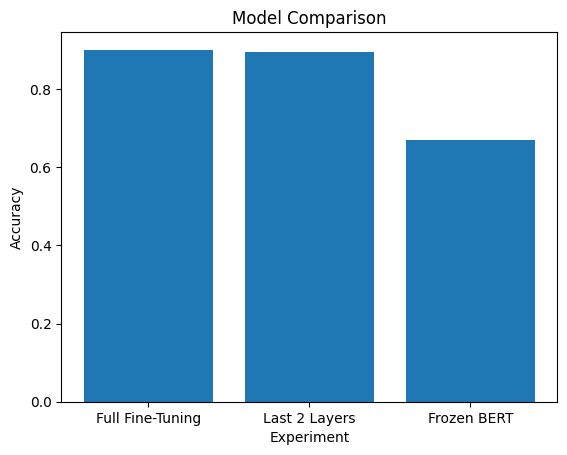

In [53]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_compare["Experiment"], df_compare["Accuracy"])
plt.xlabel("Experiment")
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

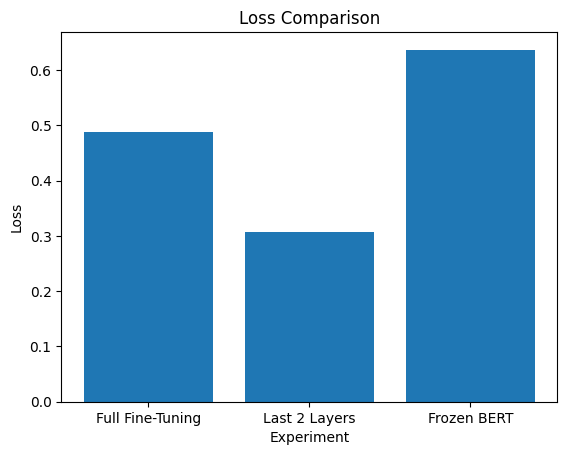

In [54]:
plt.figure()
plt.bar(df_compare["Experiment"], df_compare["Loss"])
plt.xlabel("Experiment")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.show()

## Conclusion

In this project, we built and evaluated a sentiment analysis system using the **BERT (Bidirectional Encoder Representations from Transformers)** model on the IMDB dataset.

### What was done

* Preprocessed the dataset and converted textual labels ("positive", "negative") into numeric form.
* Split the data into **training, validation, and test sets** using stratified sampling to maintain class balance.
* Tokenized the text data using a BERT tokenizer to convert raw text into model-understandable inputs.
* Created a custom PyTorch dataset to efficiently feed data into the model.

### Model Training

We experimented with three different training strategies:

1. **Full Fine-Tuning**

   * All layers of BERT were trained.
   * Achieved the highest performance but required more computational resources.

2. **Frozen BERT Layers**

   * BERT encoder was frozen and only the classification head was trained.
   * Faster training but lower performance.

3. **Partial Fine-Tuning (Last 2 Layers)**

   * Only the last two layers of BERT were unfrozen and trained.
   * Provided a balance between performance and efficiency.

### Evaluation

Each model was evaluated using multiple metrics:

* **Accuracy**
* **Precision**
* **Recall**
* **F1 Score**
* **Confusion Matrix (TN, FP, FN, TP)**

These metrics provided a comprehensive understanding of model performance, beyond just accuracy.

### Key Insights

* **Full fine-tuning** delivered the best overall performance, showing the importance of adapting pretrained models fully to the task.
* **Partial fine-tuning** offered a strong trade-off between computational cost and performance.
* **Frozen BERT** was significantly faster but less effective, highlighting the limitations of using pretrained features without adaptation.

### Final Outcome

The project demonstrates how different fine-tuning strategies impact model performance and computational efficiency. It also highlights the importance of using multiple evaluation metrics to properly assess a model.

Overall, this project provides a complete pipeline for sentiment analysis using BERT from data preprocessing to model comparison making it a strong foundation for real-world NLP applications.
